# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

Alumno: Femat Colin Viviana

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [41]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

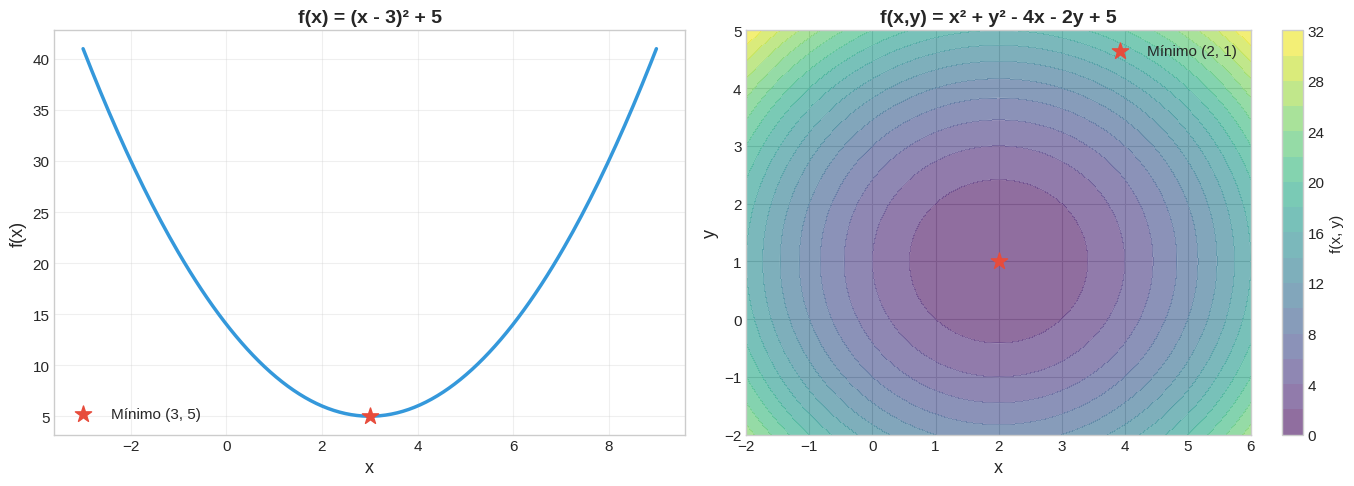

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [42]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [43]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5

    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido

    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """

    # 1. Inicializar variables
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False

    # 2. Loop principal
    for i in range(max_iter):
        g = df_1d(x_actual) # a. Calcular el gradiente (derivada en el punto actual)
        x_nuevo = x_actual - learning_rate * g # b. Actualizar la posición: descender en la dirección opuesta al gradiente

        # c. Guardar en el historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))

        # d. Verificar convergencia: si el cambio es menor que la tolerancia
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break

        # e. Actualizar x_actual para la siguiente iteración
        x_actual = x_nuevo

    # 3. Retornar resultados
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [44]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


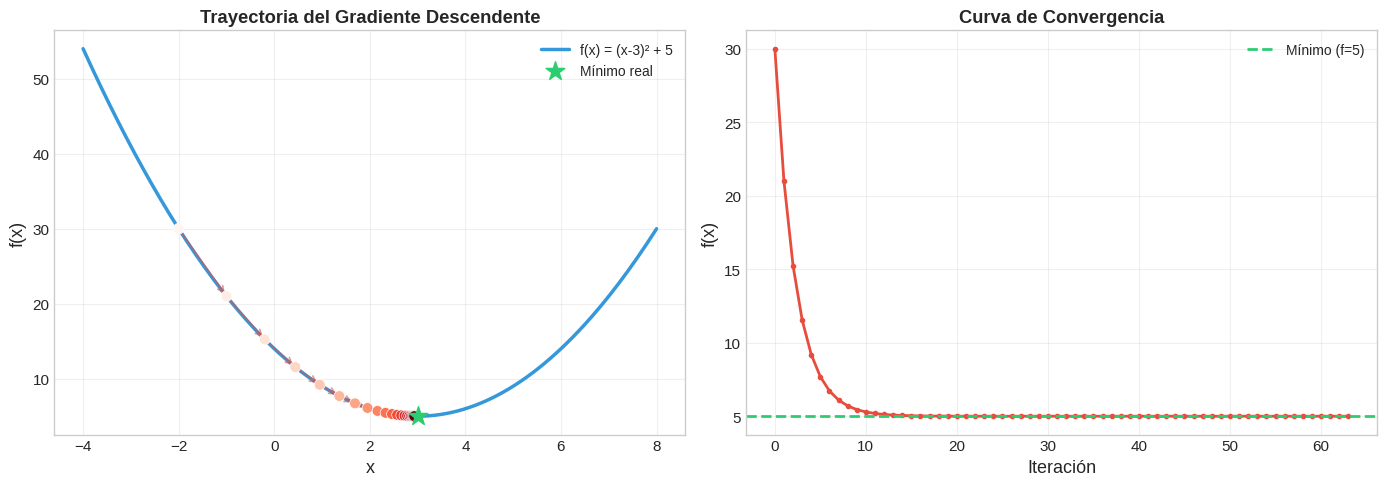

In [45]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [46]:
# Experimentos con diferentes learning rates

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# Para cada learning rate, ejecuta gradiente_descendente_1d y guarda los resultados
for l in learning_rates_prueba:
    res = gradiente_descendente_1d(
        x_inicial = x_inicial_prueba,
        learning_rate = l,
        max_iter = max_iter_prueba
    )
    resultados_lr.append(res)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

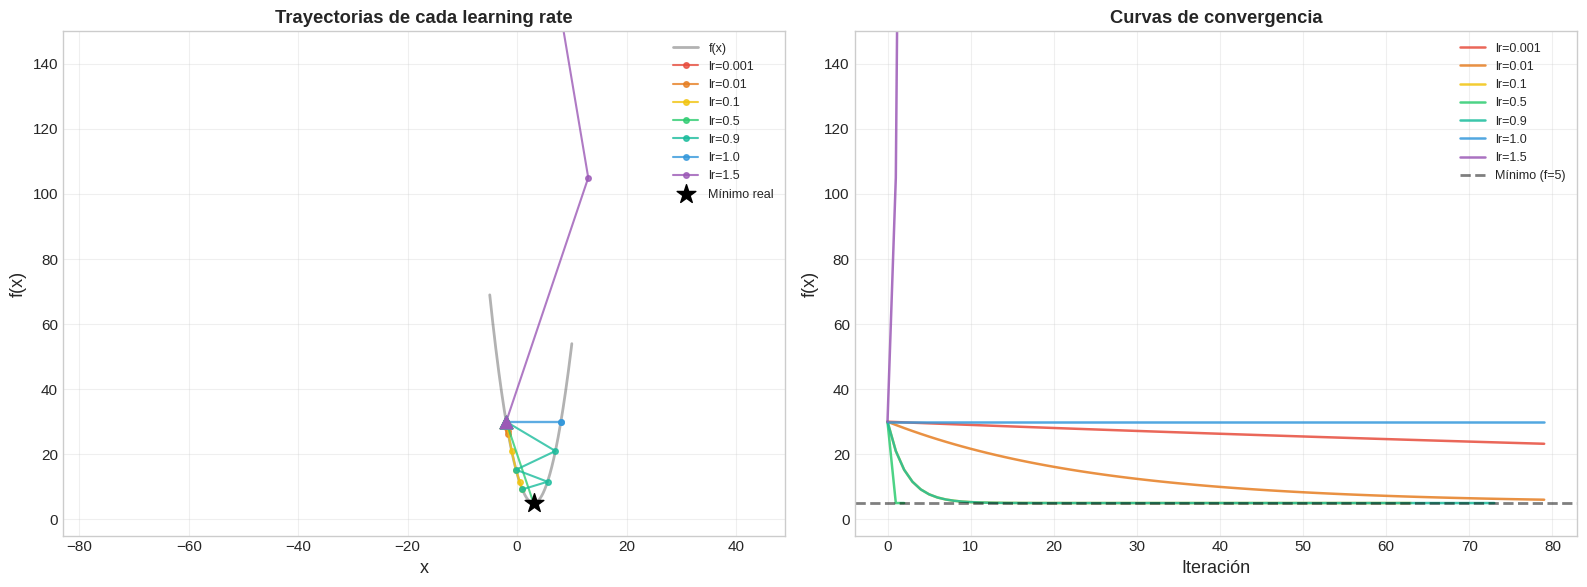

In [47]:
# Gráfica comparativa de learning rates

# Paleta de colores para distinguir cada LR
colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica de trayectoría sobre f(x)
x_range = np.linspace(-5, 10, 300)
axes[0].plot(x_range, f_1d(x_range), color='black', linewidth=2, alpha=0.3, label='f(x)', zorder=1)

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hx = res['historial_x']
    hf = res['historial_f']
    n = min(5, len(hx))  # solo muestra 5 pasos
    axes[0].plot(hx[:n], hf[:n], 'o-', color=color, linewidth=1.5,
                 markersize=4, alpha=0.8, label=f'lr={lr}')
    # Marcar punto inicial
    axes[0].scatter(hx[0], hf[0], color=color, s=80, zorder=5, marker='^')

axes[0].scatter([3], [5], color='black', s=200, marker='*', zorder=6, label='Mínimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectorias de cada learning rate', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_ylim(-5, 150)
axes[0].grid(True, alpha=0.3)

# Gráfica de la curva de convergencia
for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hf = res['historial_f']
    n = min(80, len(hf)) # solo 80 pasos
    axes[1].plot(range(n), hf[:n], color=color, linewidth=1.8,
                 alpha=0.85, label=f'lr={lr}')

axes[1].axhline(y=5, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Mínimo (f=5)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curvas de convergencia', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(-5, 150)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Responde estas preguntas basándote en tus experimentos:**

1. **¿Qué pasa con un learning rate muy pequeño (0.001)?**
   - Con l = 0.001 el algoritmo converge muy lentamente, necesitando de múltiples iteraciones para poder acercarse al valor mínimo. En este caso, ni con 200 iteraciones logra converger.

2. **¿Cuál consideras el mejor learning rate y por qué?**
   - Depende de los datos, pero en este caso parece ser mejor 0.5, ya que llega al valor en tan solo 2 iteraciones con el menor margen de error. Sin embargo, en otra situación, podría tener problemas, alejándose del valor mínimo, donde tal vez podría considerarse el 0.1 como el mejor, al dar pasos no tan pequeños que sí se acercan sin pasarse.

3. **¿Qué pasa con learning rates >= 1.0?**
   - Empiezan a divergir, los pasos son demasiado grandes, alejándose deel mínimo y f(x) comienza a crecer en lugar de disminuir.

4. **¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?**
   - La derivada de f es f'(x) = 2(x−3). Con l = 1.0 la actualización es x_nuevo = x − 1.0 * 2(x−3) = x − 2x + 6 = −x + 6. Esto hace que el algoritmo oscile entre dos puntos simétricos al mínimo sin nunca converger ni divergir.

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [48]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5

    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido

    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """

    # 1. Inicializar variables
    x_actual = x_inicial
    y_actual = y_inicial

    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False

    # 2. Loop principal
    for i in range(max_iter):
        # a. Calcular el gradiente: [df/dx, df/dy] = [2x-4, 2y-2]
        g = grad_2d(x_actual, y_actual)   # array([gx, gy])

        # b. Actualizar ambos parámetros
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]

        # c. Guardar en los historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))

        # d. Verificar convergencia: norma del gradiente < tolerancia
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            y_actual = y_nuevo
            break

        # e. Actualizar para la siguiente iteración
        x_actual = x_nuevo
        y_actual = y_nuevo

    # 3. Retornar resultados
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [49]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


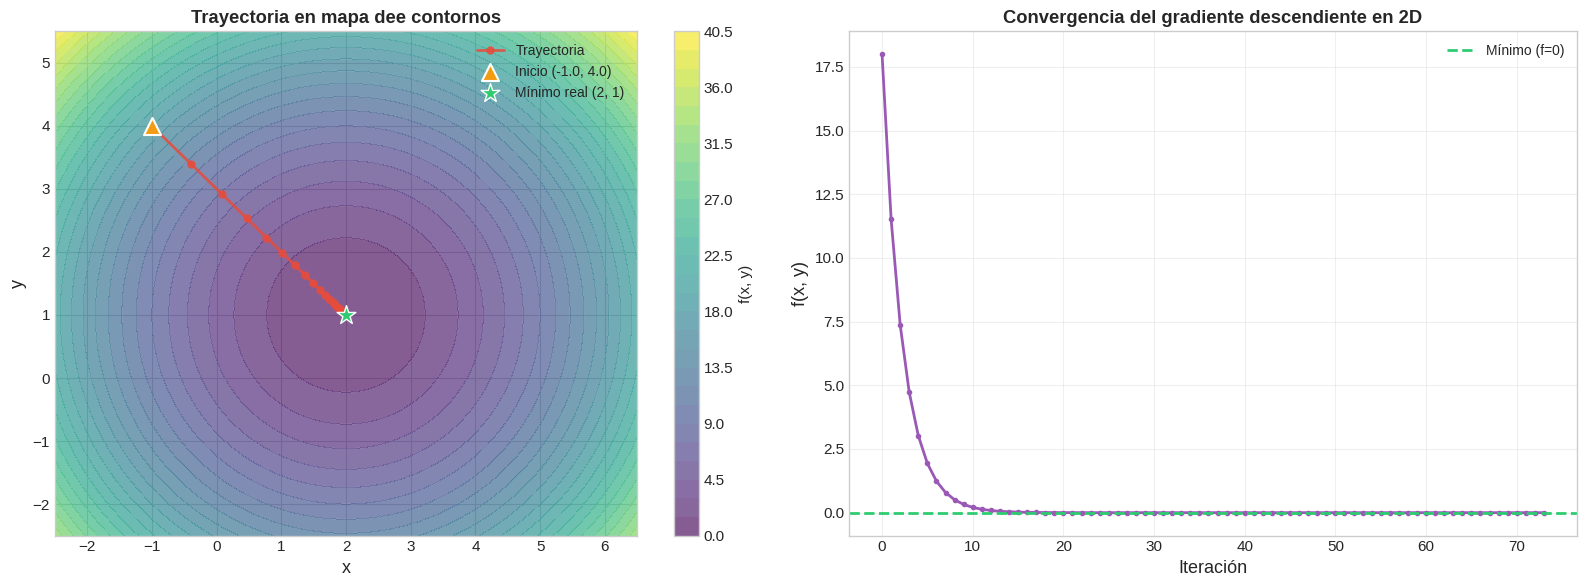

In [50]:
# Gráfica para visualizar el gradientee descendente en 2D

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica de mapas de contorno
x2 = np.linspace(-2.5, 6.5, 300)
y2 = np.linspace(-2.5, 5.5, 300)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contourf = axes[0].contourf(X2, Y2, Z2, levels=30, cmap='viridis', alpha=0.65)
axes[0].contour(X2, Y2, Z2, levels=30, colors='white', alpha=0.25, linewidths=0.5)
plt.colorbar(contourf, ax=axes[0], label='f(x, y)')

# Trayectoria del GD
hx2 = resultado_2d['historial_x']
hy2 = resultado_2d['historial_y']
axes[0].plot(hx2, hy2, 'o-', color='#e74c3c', linewidth=2,
             markersize=5, zorder=5, label='Trayectoria', alpha=0.85)
# Punto de inicio
axes[0].scatter(hx2[0], hy2[0], color='#f39c12', s=150, marker='^',
                zorder=6, edgecolors='white', linewidth=1.5, label=f'Inicio ({hx2[0]}, {hy2[0]})')
# Mínimo real
axes[0].scatter([2], [1], color='#2ecc71', s=200, marker='*',
                zorder=7, edgecolors='white', linewidth=1, label='Mínimo real (2, 1)')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Trayectoria en mapa dee contornos', fontweight='bold')
axes[0].legend(fontsize=10)

# Gráfica con la convergencia
axes[1].plot(range(len(resultado_2d['historial_f'])), resultado_2d['historial_f'],
             'o-', color='#9b59b6', linewidth=2, markersize=3)
axes[1].axhline(y=0, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=0)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x, y)', fontsize=13)
axes[1].set_title('Convergencia del gradiente descendiente en 2D', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Inicio ( -1.0,  4.0) → Final (2.0000,1.0000)  f=0.000000  iters=73
Inicio (  5.0, -1.0) → Final (2.0000,1.0000)  f=0.000000  iters=72
Inicio (  0.0,  0.0) → Final (2.0000,1.0000)  f=0.000000  iters=70


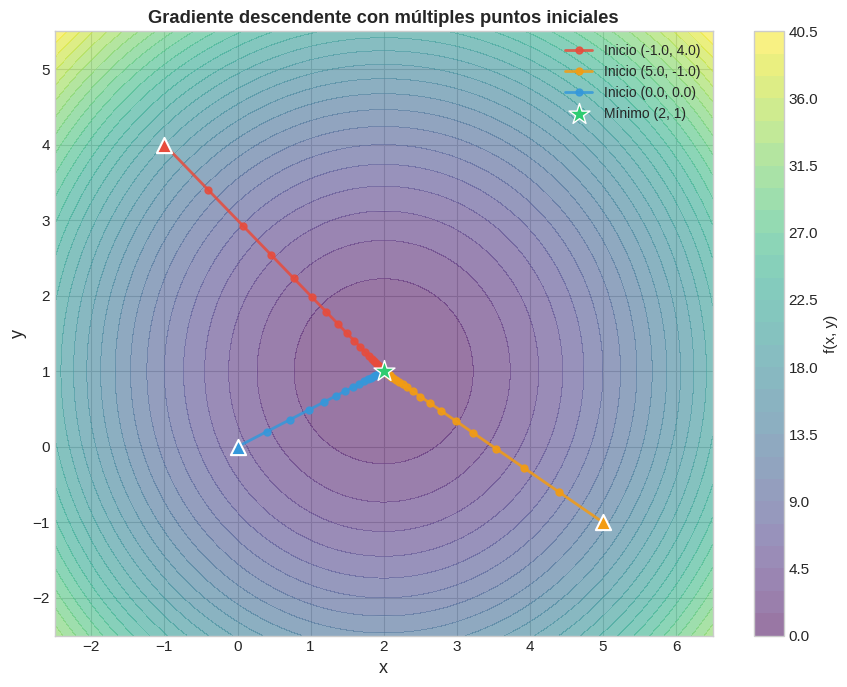

In [51]:
# EXTRA: probar con diferentes puntos iniciales

puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

resultados_2d_multi = []
for (xi, yi) in puntos_iniciales:
    res = gradiente_descendente_2d(xi, yi, learning_rate=0.1, max_iter=200)
    resultados_2d_multi.append(res)

# Visualización comparativa
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

contourf2 = ax.contourf(X2, Y2, Z2, levels=30, cmap='viridis', alpha=0.55)
ax.contour(X2, Y2, Z2, levels=30, colors='white', alpha=0.2, linewidths=0.4)
plt.colorbar(contourf2, ax=ax, label='f(x, y)')

colores_ini = ['#e74c3c', '#f39c12', '#3498db']
for (xi, yi), res, color in zip(puntos_iniciales, resultados_2d_multi, colores_ini):
    hx_ = res['historial_x']
    hy_ = res['historial_y']
    ax.plot(hx_, hy_, 'o-', color=color, linewidth=2, markersize=5,
            alpha=0.85, label=f'Inicio ({xi}, {yi})')
    ax.scatter(hx_[0], hy_[0], color=color, s=120, marker='^',
               zorder=6, edgecolors='white', linewidth=1.5)
    print(f"Inicio ({xi:5.1f},{yi:5.1f}) → Final ({res['x_final']:.4f},{res['y_final']:.4f})"
          f"  f={res['f_final']:.6f}  iters={res['iteraciones']}")

ax.scatter([2], [1], color='#2ecc71', s=250, marker='*',
           zorder=7, edgecolors='white', linewidth=1, label='Mínimo (2, 1)')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Gradiente descendente con múltiples puntos iniciales', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [52]:
# DataFrame con los experimentos

filas = []

# Experimentos 1D
lrs_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x0_1d = -2.0

for lr in lrs_1d:
    res = gradiente_descendente_1d(x_inicial=x0_1d, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr,
        'dimension':     '1D',
        'x_inicial':     x0_1d,
        'y_inicial':     float('nan'),
        'x_final':       res['x_final'],
        'y_final':       float('nan'),
        'valor_minimo':  res['f_final'],
        'iteraciones':   res['iteraciones'],
        'convergido':    res['convergido']
    })

# Experimentos 2D
lrs_2d  = [0.001, 0.01, 0.1, 0.5]
inits_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for xi, yi in inits_2d:
    for lr in lrs_2d:
        res = gradiente_descendente_2d(xi, yi, learning_rate=lr, max_iter=500)
        filas.append({
            'learning_rate': lr,
            'dimension':     '2D',
            'x_inicial':     xi,
            'y_inicial':     yi,
            'x_final':       res['x_final'],
            'y_final':       res['y_final'],
            'valor_minimo':  res['f_final'],
            'iteraciones':   res['iteraciones'],
            'convergido':    res['convergido']
        })

df_experimentos = pd.DataFrame(filas)
df_experimentos.to_csv('experimentos_gd.csv', index=False)

print(f"CSV guardado: experimentos_gd.csv")
print(f"Total de experimentos: {len(df_experimentos)}")
print(f"Experimentos 1D: {len(df_experimentos[df_experimentos.dimension=='1D'])}")
print(f"Experimentos 2D: {len(df_experimentos[df_experimentos.dimension=='2D'])}")

CSV guardado: experimentos_gd.csv
Total de experimentos: 19
Experimentos 1D: 7
Experimentos 2D: 12


In [53]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial                                                               x_final  y_final                                                                                                                      valor_minimo  iteraciones  convergido
      0.001000        1D  -2.000000        NaN                                                             -0.350258      NaN                                                                                                                         16.224229          200       False
      0.010000        1D  -2.000000        NaN                                                              2.912060      NaN                                                                                                                          5.007733          200       False
      0.100000        1D  -2.000000        NaN                                                              2.999996      N

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **¿Cuál es el rango de learning rates que funciona bien para estas funciones?**
   - Para estas funciones cuadráticas, el rango que funciona bien es [0.01, 0.5]. Con l < 0.01 la convergencia es demasiado lenta, y con l > 0.5 el algoritmo oscila o diverge.

2. **¿El punto inicial afecta si el algoritmo converge? ¿Afecta cuántas iteraciones necesita?**
   - Para funciones convexas no importa eel punto inicial, ya que solo existe un mínimo global, sin embargo, esto sí afectará a la cantidad de iteraciones necesarias. En caso de estar lejos con un lerning rate pequeño, se necesitarán múltiples iteraciones para llegar al mínimo, en cambio, si se tiene un learning rate alto, se necesitarán menos.

3. **¿Qué pasaría si la función tuviera múltiples mínimos locales? (piensa en una función como `sin(x) + x²/10`)**
   - Si hubiera múltiples mínimos locales, el gradiente descendente **quedaría atrapado** en el mínimo local más cercano al punto de partida. El algoritmo "baja" sin ver el panorama global, así que el resultado dependería fuertemente del punto inicial. Para funciones no convexas se usan técnicas como múltiples reinicios aleatorios, momentum, o métodos como Adam que ayudan a escapar de mínimos locales.
   - En caso de que haya múltiples mínimos locales, el gradiente descendiente usualmente se irá al punto más cercano a su punto de partida, sin tomar en cuenta si es global o no. En eestos casos, sería útil aplicar otros métodos para que se tome en cuenta toda la función.

4. **Conecta con ML: Cuando entrenas un modelo, los pesos son como `x` e `y`, y la función de costo es como `f(x,y)`. ¿Por qué es importante elegir bien el learning rate al entrenar?**
   - Si se tiene un learning rate muy pequeño, el modelo tardará demasiado en aprender, o no podrá hacerlo. Cuando se tienen learning rates muy altos, el modelo puede que nunca converga. Por lo tanto, elegir un buen lr estabiliza el modelo, minimizando lo más posible su costo computacional y tiempo.

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - El gradiente indica la dirección en la que existe un mayor cambio en el valor de la función, por lo tanto, garantiza que se este acercando al mínimo. Si se usarán valores al azar, se estarían gastando recursos de manera inneficiente, ya que se dejaría a la "suerte" si se encuentra el mínimo correcto, perdiendo la eficiencia que se tiene con gradiente.

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [54]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [55]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b

    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch

    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """

    n = len(X)

    # 1. Inicializar pesos en cero
    w = 0.0
    b = 0.0

    historial_loss = []
    historial_w    = [w]
    historial_b    = [b]

    # 2. Bucle de entrenamiento
    for epoch in range(epochs):
        # a. Mezclar los índices aleatoriamente
        indices = np.random.permutation(n)

        # b. Iterar sobre cada mini-batch
        for start in range(0, n, batch_size):
            batch_idx  = indices[start: start + batch_size]
            X_batch    = X[batch_idx]
            y_batch    = y[batch_idx]
            m          = len(X_batch) # tamaño real del batch

            # Predicción con los pesos actuales
            y_pred = w * X_batch + b

            # Error residual
            error  = y_batch - y_pred

            # Gradientes del MSE respecto a w y b
            dw = -2.0 / m * np.dot(error, X_batch)
            db = -2.0 / m * np.sum(error)

            # Actualización de pesos
            w -= learning_rate * dw
            b -= learning_rate * db

        # c. Calcular MSE del epoch completo y registrar
        y_pred_total = w * X + b
        mse = np.mean((y - y_pred_total) ** 2)
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    # 3. Retornar resultados
    return {
        'w_final':       w,
        'b_final':       b,
        'historial_loss': historial_loss,
        'historial_w':   historial_w,
        'historial_b':   historial_b
    }

RESULTADO SGD
  w aprendido: 3.1819  (real: 3.0)
  b aprendido: 6.1485  (real: 7.0)
  Loss final:  4.0841


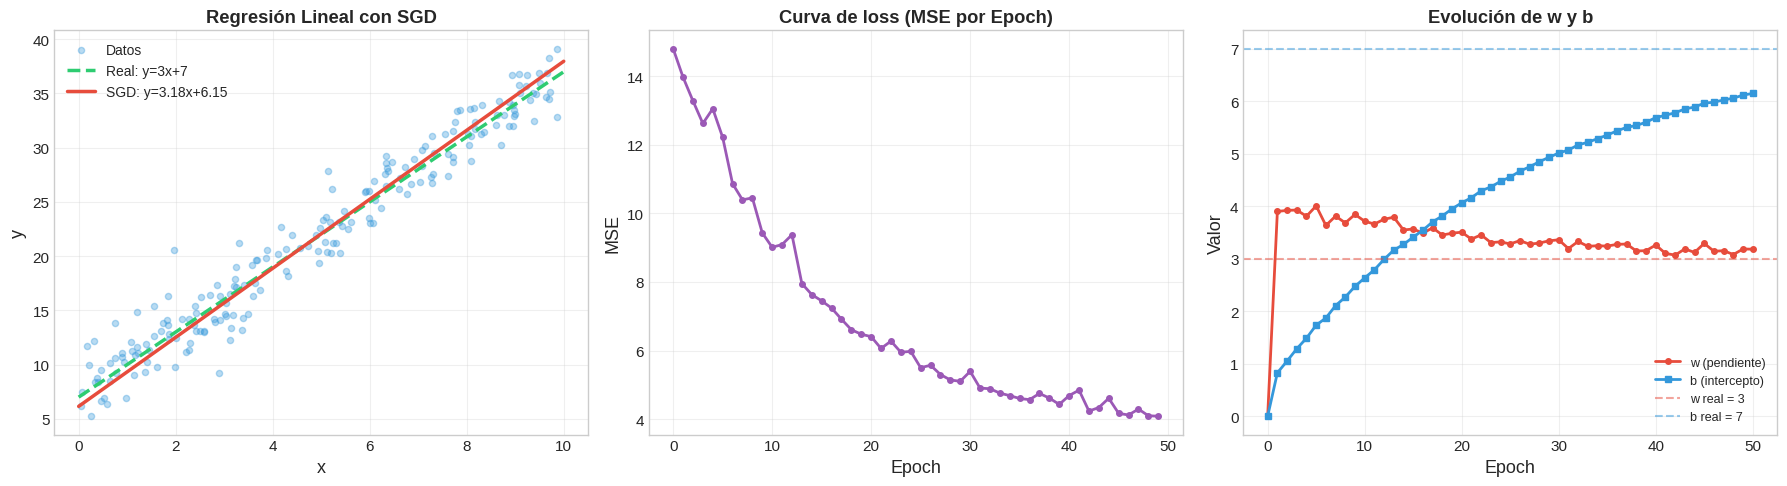

In [56]:
# Ejecuta SGD y visualiza resultados

resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

print("RESULTADO SGD")
print("=" * 45)
print(f"  w aprendido: {resultado_sgd['w_final']:.4f}  (real: 3.0)")
print(f"  b aprendido: {resultado_sgd['b_final']:.4f}  (real: 7.0)")
print(f"  Loss final:  {resultado_sgd['historial_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Real vs predicho
axes[0].scatter(X_sgd, y_sgd, alpha=0.35, color='#3498db', s=20, label='Datos')
x_line = np.linspace(0, 10, 100)
axes[0].plot(x_line, 3*x_line + 7,  color='#2ecc71', linewidth=2.5, linestyle='--', label='Real: y=3x+7')
axes[0].plot(x_line,
             resultado_sgd['w_final']*x_line + resultado_sgd['b_final'],
             color='#e74c3c', linewidth=2.5,
             label=f"SGD: y={resultado_sgd['w_final']:.2f}x+{resultado_sgd['b_final']:.2f}")
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Regresión Lineal con SGD', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Curva de loss
axes[1].plot(resultado_sgd['historial_loss'], 'o-', color='#9b59b6', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('MSE', fontsize=13)
axes[1].set_title('Curva de loss (MSE por Epoch)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Evolución de w y b
epochs_range = range(len(resultado_sgd['historial_w']))
axes[2].plot(epochs_range, resultado_sgd['historial_w'], 'o-', color='#e74c3c',
             linewidth=2, markersize=4, label='w (pendiente)')
axes[2].plot(epochs_range, resultado_sgd['historial_b'], 's-', color='#3498db',
             linewidth=2, markersize=4, label='b (intercepto)')
axes[2].axhline(y=3, color='#e74c3c', linestyle='--', alpha=0.5, label='w real = 3')
axes[2].axhline(y=7, color='#3498db', linestyle='--', alpha=0.5, label='b real = 7')
axes[2].set_xlabel('Epoch', fontsize=13)
axes[2].set_ylabel('Valor', fontsize=13)
axes[2].set_title('Evolución de w y b', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

     SGD (bs=1) -> w=3.1652, b=7.2894, loss=4.9282
           bs=8 -> w=2.9206, b=7.2004, loss=3.8719
          bs=32 -> w=3.1347, b=6.1625, loss=4.0334
          bs=64 -> w=3.1576, b=4.8955, loss=6.1755
      GD (bs=N) -> w=3.7556, b=2.1410, loss=10.6685


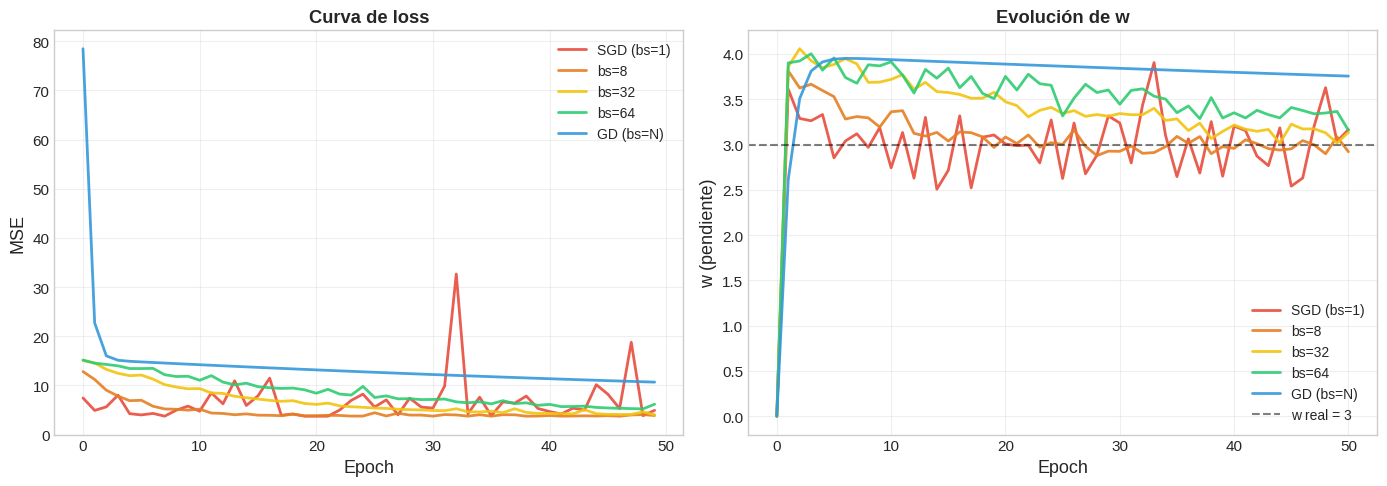

In [57]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

batch_sizes = [1, 8, 32, 64, n_datos]
etiquetas   = ['SGD (bs=1)', 'bs=8', 'bs=32', 'bs=64', 'GD (bs=N)']
colores_bs  = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

resultados_bs = {}
for bs, label in zip(batch_sizes, etiquetas):
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    resultados_bs[label] = res

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (label, res), color in zip(resultados_bs.items(), colores_bs):
    axes[0].plot(res['historial_loss'], color=color, linewidth=2, alpha=0.9, label=label)
    print(f"{label:>15} -> w={res['w_final']:.4f}, b={res['b_final']:.4f}, loss={res['historial_loss'][-1]:.4f}")

axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('MSE', fontsize=13)
axes[0].set_title('Curva de loss', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Evolución de w
for (label, res), color in zip(resultados_bs.items(), colores_bs):
    axes[1].plot(res['historial_w'], color=color, linewidth=2, alpha=0.9, label=label)
axes[1].axhline(y=3, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='w real = 3')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('w (pendiente)', fontsize=13)
axes[1].set_title('Evolución de w', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Preguntas Bonus:**

1. **¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - El gradiente descendente puro tiene una curva de loss suave y monotónica, mientras que SGD puro tiene picos de varianza. Sin embargo, SGD es más rápido en iteraciones.

2. **¿Cuál batch_size te dio los mejores resultados? ¿Por qué?**
   - En este caso, el mejor gue de 1, ya que tiene el menor valor de loss, este evita quedarse valles y puede encontrar mejores mínimos. Sin embargo, cuando se usan batch_size grandes, lo mejor sería probar con un valor de learning rate más alto, ya que los hace más estables.

3. **¿Por qué la curva de loss de SGD es más ruidosa que la de GD?**
   - Al ser un proceso estocástico, cada paso es un subconjunto aleatorio de los datos, en estos casos, la varianza del gradiente es inversamente proporcional al tamaño del batch. Al ser este el valor mínimo en SGD (1), se introduce la máxima cantidad de ruido, mientras que al usarse la máxima cantidad de bs (en GD), se elimina por completo el ruido.

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [X] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [X] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [X] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [X] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [X] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_